In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#ファイル読み込み
train = pd.read_csv('../000.data/train/train_A.tsv', sep="\t")

In [3]:
#各列の情報確認
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376493 entries, 0 to 3376492
Data columns (total 5 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   user_id     object
 1   product_id  object
 2   event_type  int64 
 3   ad          int64 
 4   time_stamp  object
dtypes: int64(2), object(3)
memory usage: 128.8+ MB


In [4]:
#基本的な統計情報の確認
train.describe()

,event_type,ad
count,3.376493e+06,3.376493e+06
mean,6.729737e-01,-9.609183e-01
std,6.102185e-01,2.674938e-01
min,0.000000e+00,-1.000000e+00
25%,0.000000e+00,-1.000000e+00
50%,1.000000e+00,-1.000000e+00
75%,1.000000e+00,-1.000000e+00
max,3.000000e+00,1.000000e+00


In [5]:
#カテゴリーデータ(文字列データ)の統計情報の確認
train.describe(include='object')

,user_id,product_id,time_stamp
count,3376493,3376493,3376493
unique,58658,13866,2425773
top,0025154_A,00005175_a,2017-04-27 05:41:09.113
freq,11987,11688,18


In [6]:
#データ欠損行数の確認
train.isnull().sum()

user_id       0
product_id    0
event_type    0
ad            0
time_stamp    0
dtype: int64

In [7]:
#重複行数の確認
train.duplicated().sum()

17

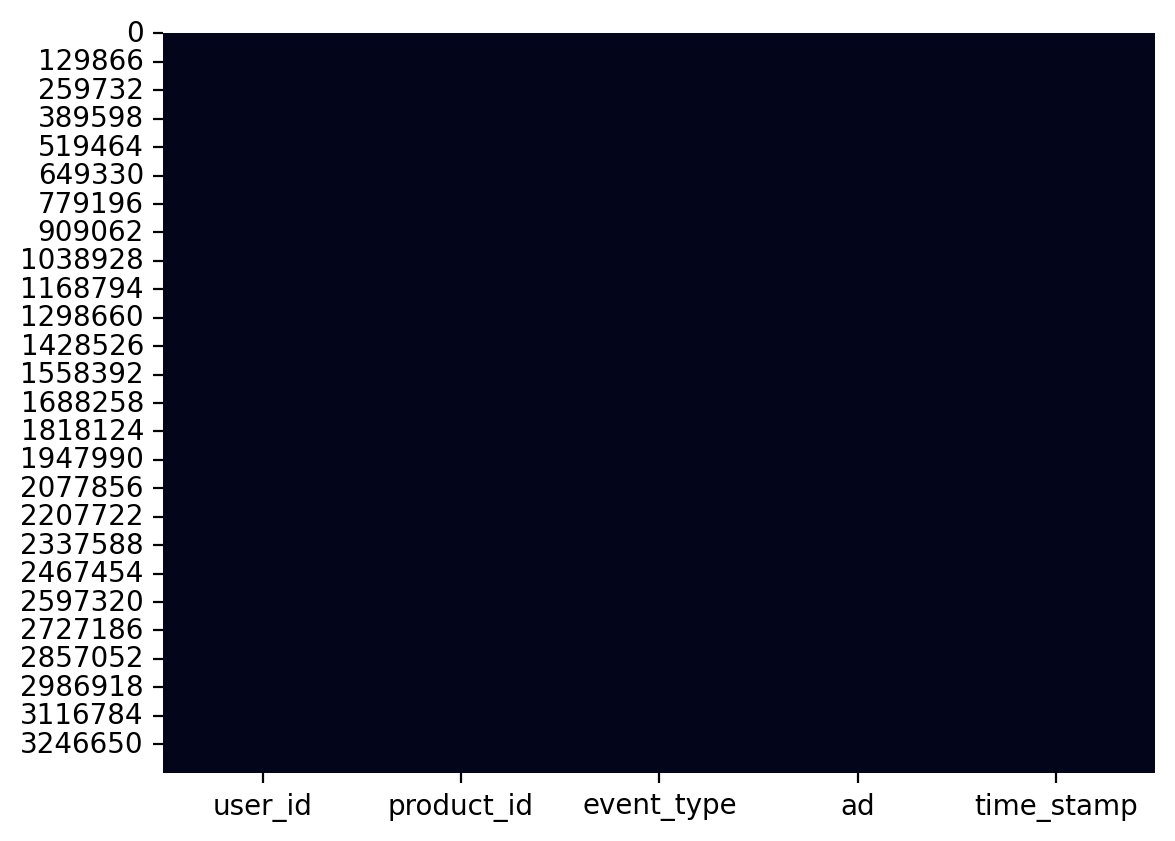

In [8]:
#データ欠損値(NaN)の可視化
sns.heatmap(train.isnull(),cbar=False)
plt.show()

In [9]:
#行動種別(event_type)毎の数
train['event_type'].value_counts()

event_type
1    1981780
0    1286738
3      74561
2      33414
Name: count, dtype: int64

In [10]:
#コンバージョンの数
train['ad'].value_counts()

ad
-1    3301932
 1      57398
 0      17163
Name: count, dtype: int64

In [11]:
time_stamp = train.drop(['user_id', 'product_id', 'ad'], axis=1)

In [12]:
time_stamp.duplicated().sum()

950238

In [13]:
# user_id と time_stamp ごとの出現回数をカウント
counts = train.groupby(["user_id", "time_stamp"]).size().reset_index(name="count")

In [14]:
# 2回以上出現するもののみ表示
duplicate_counts = counts[counts["count"] > 1]
print(duplicate_counts)

           user_id               time_stamp  count
106      0000003_A  2017-04-04 00:54:10.372      3
148      0000005_A  2017-04-04 06:33:30.974     10
157      0000005_A  2017-04-07 06:25:55.468     10
160      0000005_A  2017-04-11 06:28:49.292      9
161      0000005_A  2017-04-11 06:29:40.594      9
...            ...                      ...    ...
2427248  0058654_A  2017-04-27 05:02:37.393      2
2427315  0058657_A  2017-04-07 00:18:19.975      4
2427319  0058657_A  2017-04-21 03:27:41.183      3
2427336  0058657_A  2017-04-24 06:28:12.998      4
2427337  0058657_A  2017-04-24 06:36:51.952      4

[148379 rows x 3 columns]
